In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('diabetes.csv')

In [4]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
print(df.shape)

(768, 9)


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [7]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [8]:
zero_counts = (df[['Glucose', 'BloodPressure', 'BMI', 'Insulin', 'SkinThickness']] == 0).sum()
print(zero_counts)

Glucose            5
BloodPressure     35
BMI               11
Insulin          374
SkinThickness    227
dtype: int64


In [9]:
# Replace zeros with median for low missing columns
for col in ['Glucose', 'BloodPressure', 'BMI']:
    median = df[col].median()
    df[col] = df[col].replace(0, median)

# Drop high missing columns
df = df.drop(columns=['Insulin', 'SkinThickness'])

# Verify no zeros remain
print(df[['Glucose', 'BloodPressure', 'BMI']].min())
print(df.shape)

Glucose          44.0
BloodPressure    24.0
BMI              18.2
dtype: float64
(768, 7)


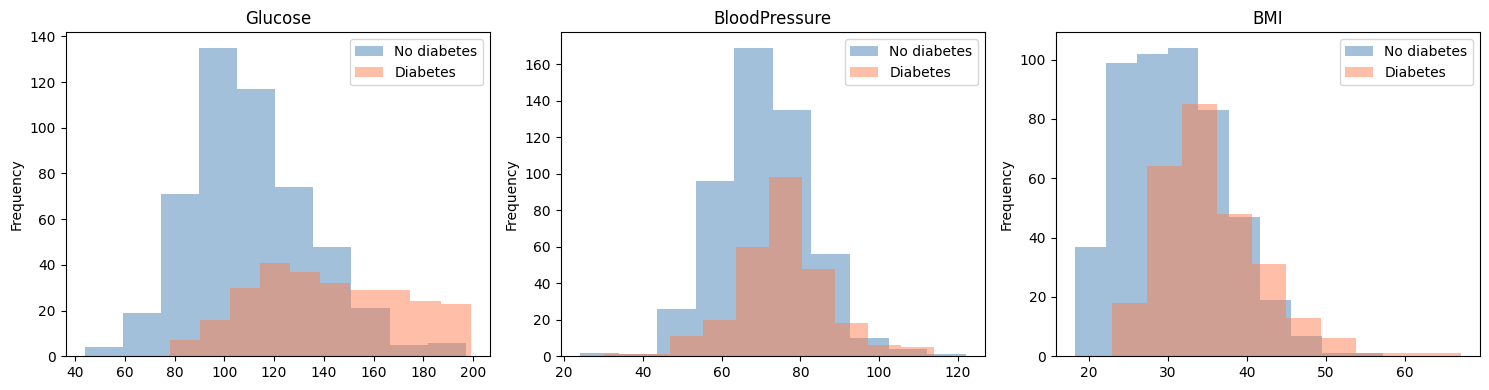

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['Glucose', 'BloodPressure', 'BMI']):
    df[df['Outcome'] == 0][col].plot(kind='hist', ax = ax, alpha = 0.5, label='No Diabetes', color='steelblue')
    df[df['Outcome'] == 1][col].plot(kind='hist', ax = ax, alpha = 0.5, label='Diabetes', color='coral')

    ax.set_title(col)
    ax.legend()

plt.tight_layout()
plt.show()